In [5]:
import numpy as np
import pandas as pd

import io
import os
import tensorflow as tf

from PIL import Image
from glob import glob
import itertools

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, BatchNormalization, Dropout, Dense, MaxPool2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from IPython.display import display
#To see the value of multiple statements at once.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [6]:
""" import os
import shutil
import pandas as pd

# Paths
image_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\images"
metadata_path = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\metadata.csv"

# ✅ Updated output path
output_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images"

# Read metadata
df = pd.read_csv(metadata_path)

# Process each image
for _, row in df.iterrows():
    isic_id = row['isic_id'].strip()
    label = str(row['diagnosis']).strip().replace("/", "-")

    filename = f"{isic_id}.jpg"
    src_path = os.path.join(image_dir, filename)
    dst_folder = os.path.join(output_dir, label)
    dst_path = os.path.join(dst_folder, filename)

    os.makedirs(dst_folder, exist_ok=True)

    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
    else:
        print(f"Missing file: {filename}")
 """

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 70-71: truncated \UXXXXXXXX escape (523872643.py, line 31)

# read the data

=== Loading HIBA Dataset ===
Base directory: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images
No CSV metadata file found. Creating basic structure from image files...
Created DataFrame with 1386 images

=== Preprocessing Data ===
Removed 0 rows with missing diagnosis
Diagnosis mapping: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'seborrheic keratosis': 5, 'solar lentigo': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}
Found 1386/1386 valid image paths
Final dataset: 1386 samples with 9 unique diagnoses

=== Dataset Summary ===
Total samples: 1386
Total unique diagnoses: 9
Columns: ['isic_id', 'diagnosis', 'image_path', 'diagnosis_label']

No missing values found

Data types:
  isic_id: object
  diagnosis: object
  image_path: object
  diagnosis_label: int64

=== Dataset Analysis ===
Class distribution:
  

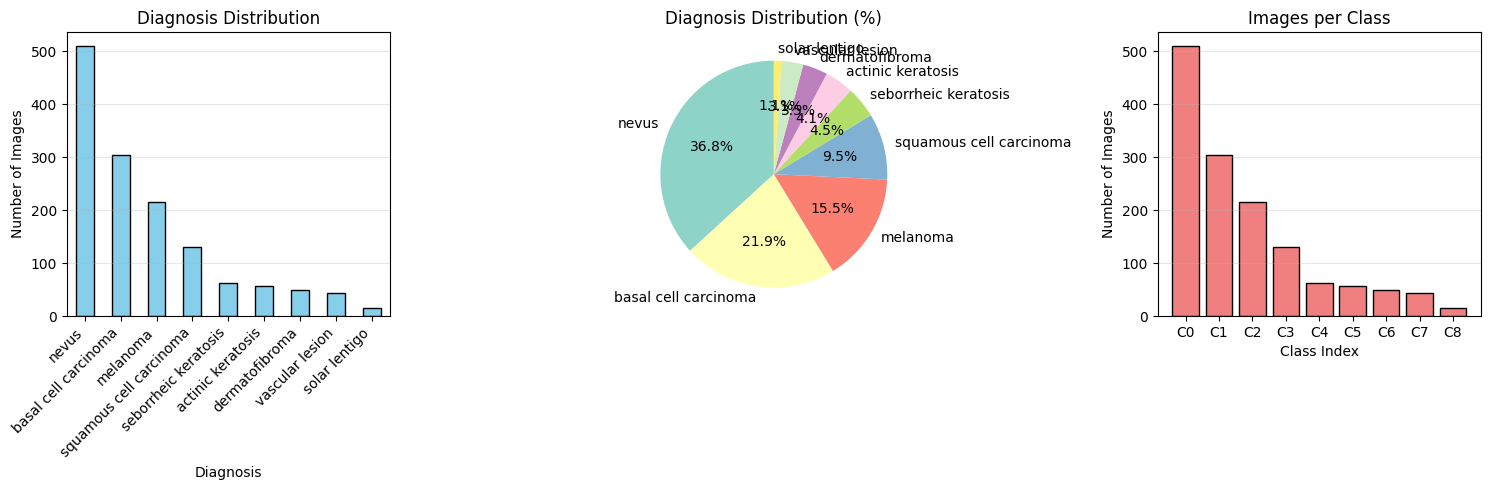


=== Visualizing Sample Images ===
Found 9 unique diagnoses


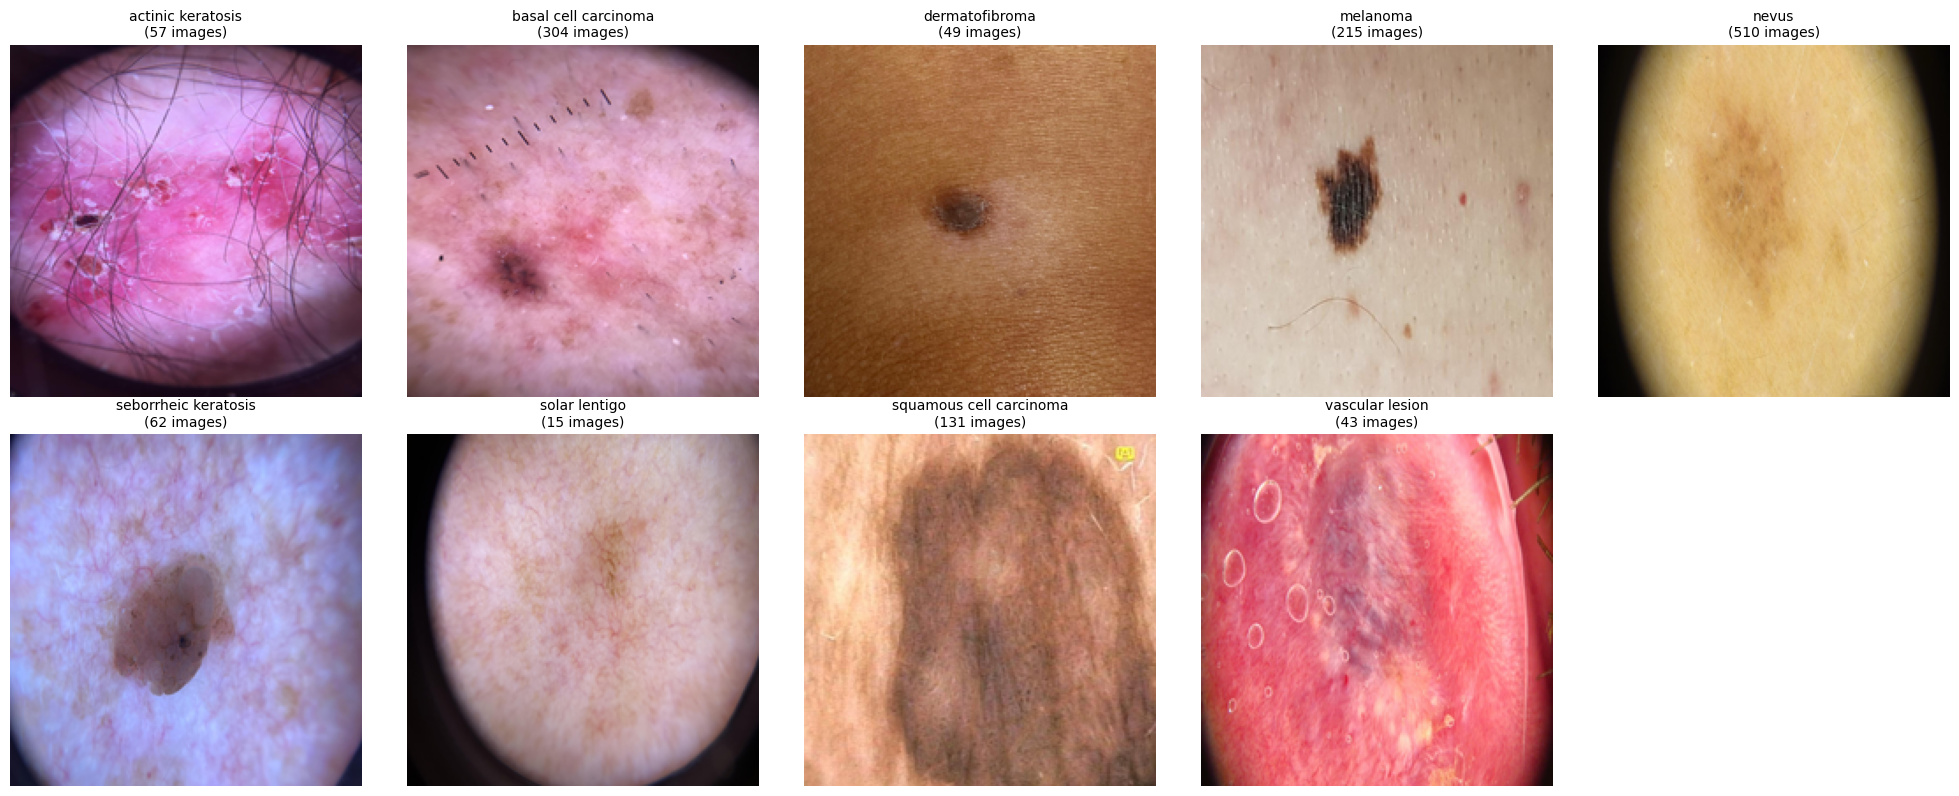


Dataset exploration complete!
Final dataset shape: (1386, 4)


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

def load_hiba_dataset(base_dir):
    """Load and explore the HIBA dataset structure"""
    print("=== Loading HIBA Dataset ===")
    print(f"Base directory: {base_dir}")
    
    # Check if base directory exists
    if not os.path.exists(base_dir):
        print(f"ERROR: Base directory does not exist: {base_dir}")
        return None
    
    # Look for CSV metadata file
    csv_files = glob(os.path.join(base_dir, "*.csv"))
    if csv_files:
        print(f"Found CSV files: {csv_files}")
        # Load the first CSV file found
        df = pd.read_csv(csv_files[0])
        print(f"Loaded CSV with {len(df)} rows and {df.shape[1]} columns")
        print(f"Columns: {list(df.columns)}")
    else:
        print("No CSV metadata file found. Creating basic structure from image files...")
        df = create_basic_dataframe_from_images(base_dir)
    
    return df

def create_basic_dataframe_from_images(base_dir):
    """Create a basic DataFrame from image files if no CSV is available"""
    # Look for image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
    all_images = []
    
    for ext in image_extensions:
        all_images.extend(glob(os.path.join(base_dir, ext)))
        all_images.extend(glob(os.path.join(base_dir, "**", ext), recursive=True))
    
    if not all_images:
        print("No images found!")
        return None
    
    # Create basic DataFrame
    data_list = []
    for img_path in all_images:
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        
        # Try to infer diagnosis from folder structure
        parent_dir = os.path.basename(os.path.dirname(img_path))
        if parent_dir != os.path.basename(base_dir):
            diagnosis = parent_dir
        else:
            diagnosis = 'unknown'
        
        data_list.append({
            'isic_id': img_name,
            'diagnosis': diagnosis,
            'image_path': img_path
        })
    
    df = pd.DataFrame(data_list)
    print(f"Created DataFrame with {len(df)} images")
    return df

def preprocess_hiba_data(df, base_dir):
    """Preprocess the HIBA dataset"""
    print("\n=== Preprocessing Data ===")
    
    if df is None:
        return None
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Check if 'diagnosis' column exists
    if 'diagnosis' not in df.columns:
        print("No 'diagnosis' column found. Looking for alternative diagnosis columns...")
        
        # Look for potential diagnosis columns
        potential_cols = [col for col in df.columns if 'diagnosis' in col.lower()]
        if potential_cols:
            print(f"Found potential diagnosis columns: {potential_cols}")
            df['diagnosis'] = df[potential_cols[0]]
        else:
            print("No diagnosis information found. Creating dummy diagnosis...")
            df['diagnosis'] = 'unknown'
    
    # Drop rows with missing diagnosis
    initial_count = len(df)
    df.dropna(subset=['diagnosis'], inplace=True)
    print(f"Removed {initial_count - len(df)} rows with missing diagnosis")
    
    # Encode 'diagnosis' to numeric labels
    diagnosis_mapping = {label: idx for idx, label in enumerate(df['diagnosis'].unique())}
    df['diagnosis_label'] = df['diagnosis'].map(diagnosis_mapping)
    
    print(f"Diagnosis mapping: {diagnosis_mapping}")
    
    # Create image_path if it doesn't exist
    if 'image_path' not in df.columns:
        if 'isic_id' in df.columns:
            df['image_path'] = df['isic_id'].apply(lambda x: find_image_path(x, base_dir))
        else:
            print("WARNING: Cannot create image paths - no 'isic_id' column found")
            return df
    
    # Check if image paths exist
    existing_paths = df['image_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) else False)
    valid_count = existing_paths.sum()
    print(f"Found {valid_count}/{len(df)} valid image paths")
    
    # Keep only rows with valid image paths
    df = df[existing_paths].copy()
    
    # Drop unnecessary columns safely
    columns_to_drop = ['attribution', 'copyright_license', 'anatom_site_general', 'anatom_site_special',
                       'benign_malignant', 'concomitant_biopsy', 'dermoscopic_type','diagnosis_1', 'diagnosis_2', 'diagnosis_3',
                       'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id',
                       'patient_id', 'personal_hx_mm', 'sex']
    
    # Only drop columns that actually exist
    existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
    if existing_columns_to_drop:
        df.drop(columns=existing_columns_to_drop, inplace=True)
        print(f"Dropped columns: {existing_columns_to_drop}")
    
    print(f"Final dataset: {len(df)} samples with {len(df['diagnosis'].unique())} unique diagnoses")
    
    return df

def find_image_path(image_id, base_dir):
    """Find the full path for an image ID"""
    image_extensions = ['jpg', 'jpeg', 'png', 'bmp', 'tiff']
    
    for ext in image_extensions:
        # Try different possible paths
        possible_paths = [
            os.path.join(base_dir, f"{image_id}.{ext}"),
            os.path.join(base_dir, "**", f"{image_id}.{ext}")
        ]
        
        for path_pattern in possible_paths:
            matches = glob(path_pattern, recursive=True)
            if matches:
                return matches[0]
    
    return None

def analyze_dataset_distribution(df):
    """Analyze and visualize the dataset distribution"""
    print("\n=== Dataset Analysis ===")
    
    if df is None or len(df) == 0:
        print("No data to analyze")
        return
    
    # Class distribution
    class_counts = df['diagnosis'].value_counts()
    print("Class distribution:")
    for diagnosis, count in class_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {diagnosis}: {count} images ({percentage:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Bar plot
    plt.subplot(1, 3, 1)
    class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Diagnosis Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Pie chart
    plt.subplot(1, 3, 2)
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
    plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    plt.title('Diagnosis Distribution (%)')
    
    # Box plot of class sizes (if meaningful)
    plt.subplot(1, 3, 3)
    plt.bar(range(len(class_counts)), class_counts.values, color='lightcoral', edgecolor='black')
    plt.title('Images per Class')
    plt.xlabel('Class Index')
    plt.ylabel('Number of Images')
    plt.xticks(range(len(class_counts)), [f"C{i}" for i in range(len(class_counts))])
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

def visualize_sample_images(df, max_samples_per_class=1):
    """Visualize sample images for each diagnosis"""
    print(f"\n=== Visualizing Sample Images ===")
    
    if df is None or len(df) == 0:
        print("No data to visualize")
        return
    
    unique_diagnoses = df['diagnosis'].unique()
    n_diagnoses = len(unique_diagnoses)
    
    print(f"Found {n_diagnoses} unique diagnoses")
    
    # Calculate grid size
    cols = min(5, n_diagnoses)
    rows = (n_diagnoses + cols - 1) // cols
    
    plt.figure(figsize=(4*cols, 4*rows))
    
    for i, diagnosis in enumerate(unique_diagnoses):
        # Get samples for this diagnosis
        diagnosis_samples = df[df['diagnosis'] == diagnosis]
        
        if len(diagnosis_samples) == 0:
            continue
        
        # Take up to max_samples_per_class
        samples_to_show = min(max_samples_per_class, len(diagnosis_samples))
        
        for j in range(samples_to_show):
            sample_image = diagnosis_samples.iloc[j]
            img_path = sample_image['image_path']
            
            try:
                # Load and display image
                img = Image.open(img_path)
                
                # Convert to RGB if necessary
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Resize for consistent display
                img = img.resize((200, 200), Image.LANCZOS)
                
                plt.subplot(rows, cols, i + 1)
                plt.imshow(img)
                plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
                plt.axis("off")
                
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
                plt.subplot(rows, cols, i + 1)
                plt.text(0.5, 0.5, f"Error loading\n{diagnosis}", 
                        ha='center', va='center', transform=plt.gca().transAxes)
                plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
                plt.axis("off")
    
    plt.tight_layout()
    plt.show()

def generate_dataset_summary(df):
    """Generate a comprehensive dataset summary"""
    print("\n=== Dataset Summary ===")
    
    if df is None:
        print("No dataset loaded")
        return
    
    print(f"Total samples: {len(df)}")
    print(f"Total unique diagnoses: {len(df['diagnosis'].unique())}")
    print(f"Columns: {list(df.columns)}")
    
    # Missing values
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        print("\nMissing values:")
        for col, missing_count in missing_data.items():
            if missing_count > 0:
                print(f"  {col}: {missing_count}")
    else:
        print("\nNo missing values found")
    
    # Data types
    print(f"\nData types:")
    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")

def main():
    """Main function to run the HIBA dataset exploration"""
    # Set the base directory
    base_skin_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images"
    
    # Load dataset
    df = load_hiba_dataset(base_skin_dir)
    
    if df is None:
        print("Failed to load dataset")
        return None
    
    # Preprocess data
    df = preprocess_hiba_data(df, base_skin_dir)
    
    if df is None or len(df) == 0:
        print("No valid data after preprocessing")
        return None
    
    # Generate summary
    generate_dataset_summary(df)
    
    # Analyze distribution
    class_counts = analyze_dataset_distribution(df)
    
    # Visualize samples
    visualize_sample_images(df, max_samples_per_class=1)
    
    print(f"\nDataset exploration complete!")
    print(f"Final dataset shape: {df.shape}")
    
    return df

# Run the exploration
if __name__ == "__main__":
    df = main()

Preproceesing

=== HIBA Dataset GAN Augmentation Pipeline ===
GPU memory growth enabled for 1 GPU(s)
Loading HIBA dataset...
=== Loading HIBA Organized Dataset ===
Found class folders: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'seborrheic keratosis', 'solar lentigo', 'squamous cell carcinoma', 'vascular lesion']
Class 'actinic keratosis': 114 images
Class 'basal cell carcinoma': 608 images
Class 'dermatofibroma': 98 images
Class 'melanoma': 430 images
Class 'nevus': 1020 images
Class 'seborrheic keratosis': 124 images
Class 'solar lentigo': 30 images
Class 'squamous cell carcinoma': 262 images
Class 'vascular lesion': 86 images
Created DataFrame with 2772 images and 9 classes
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'seborrheic keratosis', 'solar lentigo', 'squamous cell carcinoma', 'vascular lesion']

=== Class Distribution Analysis ===
nevus: 1020 images
basal cell carcinoma: 608 images
melanoma: 430 ima

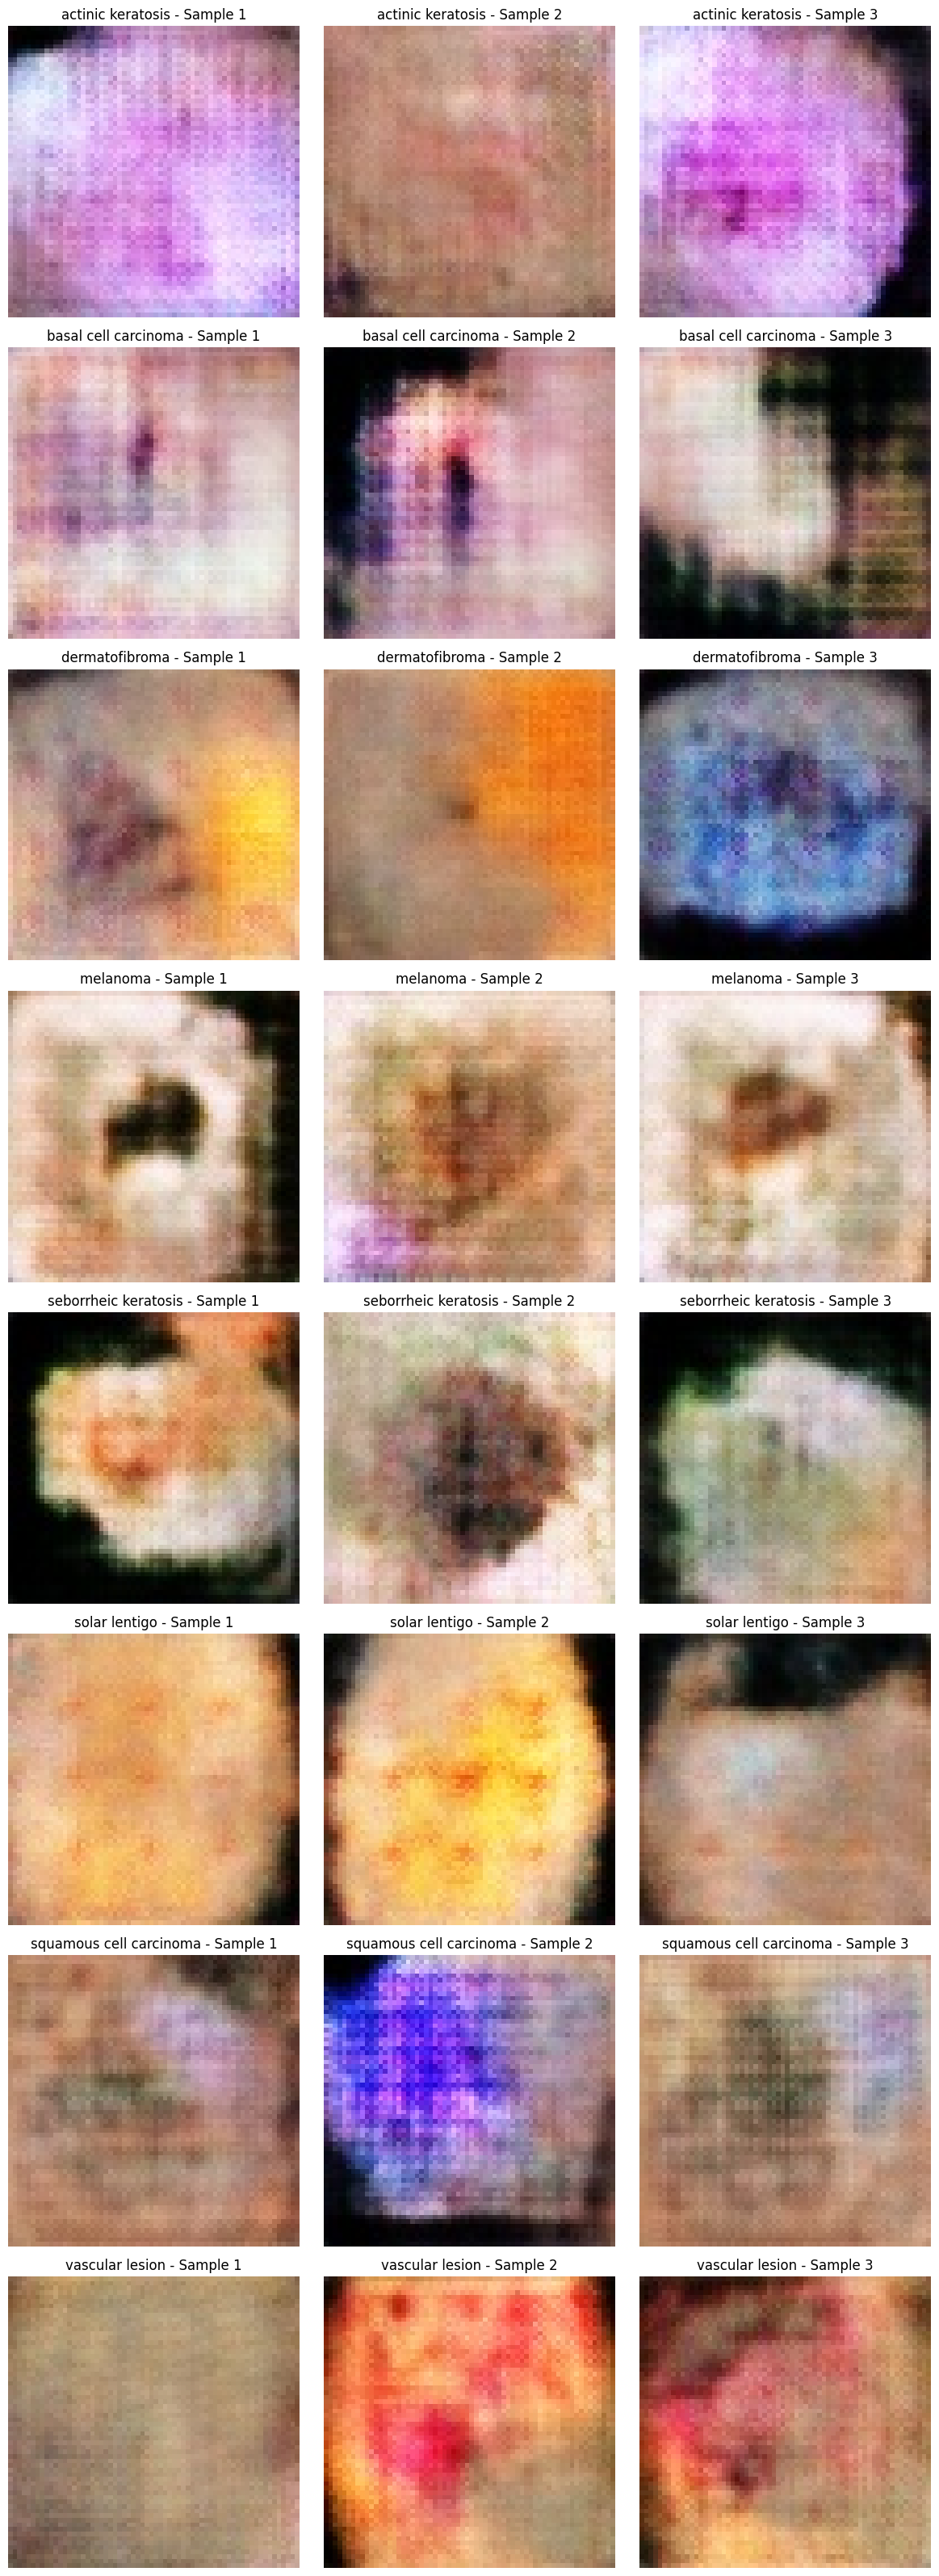

In [ ]:
""" import numpy as np
import pandas as pd
import os
import time
import tensorflow as tf
from PIL import Image, ImageFilter
from glob import glob
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Conv2D, Conv2DTranspose, Reshape, LeakyReLU, LayerNormalization, Flatten, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import gc
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

class Config:
    IMAGE_SIZE = 224
    BATCH_SIZE = 16
    BASE_DIR = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions"
    SORTED_IMAGES_DIR = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images"
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.2
    
    GAN_IMAGE_SIZE = 64
    GAN_BATCH_SIZE = 4
    LATENT_DIM = 100
    GAN_EPOCHS = 500  # Reduced for faster training

config = Config()

def clear_memory():
    gc.collect()
    tf.keras.backend.clear_session()
    print("Memory cleared")

def setup_gpu():
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
        except RuntimeError as e:
            print(f"GPU configuration error: {e}")
    else:
        print("No GPU found. Using CPU.")

def load_hiba_organized_dataset():
    """Load the organized HIBA dataset"""
    print("=== Loading HIBA Organized Dataset ===")
    
    if not os.path.exists(config.SORTED_IMAGES_DIR):
        print(f"ERROR: Sorted images directory not found: {config.SORTED_IMAGES_DIR}")
        return None
    
    # Get all class folders
    class_folders = [d for d in os.listdir(config.SORTED_IMAGES_DIR) 
                    if os.path.isdir(os.path.join(config.SORTED_IMAGES_DIR, d))]
    
    print(f"Found class folders: {class_folders}")
    
    # Create DataFrame from organized structure
    data_list = []
    for class_name in class_folders:
        class_path = os.path.join(config.SORTED_IMAGES_DIR, class_name)
        
        # Find all images in this class folder
        image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.JPG', '*.JPEG', '*.PNG']
        class_images = []
        
        for ext in image_extensions:
            class_images.extend(glob(os.path.join(class_path, ext)))
        
        print(f"Class '{class_name}': {len(class_images)} images")
        
        # Add to data list
        for img_path in class_images:
            img_name = os.path.splitext(os.path.basename(img_path))[0]
            data_list.append({
                'image_id': img_name,
                'dx': class_name,
                'path': img_path
            })
    
    df = pd.DataFrame(data_list)
    
    # Create label mappings
    unique_classes = sorted(df['dx'].unique())
    reverse_label_mapping = {class_name: idx for idx, class_name in enumerate(unique_classes)}
    label_mapping = {idx: class_name for class_name, idx in reverse_label_mapping.items()}
    
    df['label'] = df['dx'].map(reverse_label_mapping)
    
    print(f"Created DataFrame with {len(df)} images and {len(unique_classes)} classes")
    print(f"Classes: {unique_classes}")
    
    return df, label_mapping, reverse_label_mapping

def enhanced_load_image_pixels(image_path, target_size=224):
    if not image_path or not os.path.exists(image_path):
        return None
    try:
        image = Image.open(image_path)
        if image.mode != 'RGB':
            image = image.convert('RGB')
        image = image.resize((target_size, target_size), Image.LANCZOS)
        return np.asarray(image)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def build_generator():
    model = tf.keras.Sequential()
    model.add(Dense(4 * 4 * 256, use_bias=False, input_shape=(config.LATENT_DIM,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((4, 4, 256)))
    
    model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    
    model.add(Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    
    model.add(Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    
    model.add(Conv2DTranspose(16, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    
    model.add(Conv2D(3, (3, 3), padding='same', activation='tanh', use_bias=False))
    return model

def build_discriminator():
    inputs = Input(shape=(config.GAN_IMAGE_SIZE, config.GAN_IMAGE_SIZE, 3))
    x = Conv2D(32, (4, 4), strides=(2, 2), padding='same')(inputs)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)
    
    x = Conv2D(64, (4, 4), strides=(2, 2), padding='same')(x)
    x = LayerNormalization()(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)
    
    x = Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = LayerNormalization()(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)
    
    x = Flatten()(x)
    outputs = Dense(1)(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

def gradient_penalty(discriminator, real_images, fake_images, batch_size):
    alpha = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
    diff = fake_images - real_images
    interpolated = real_images + alpha * diff
    
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        pred = discriminator(interpolated, training=True)
    
    grads = gp_tape.gradient(pred, [interpolated])[0]
    norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
    return tf.reduce_mean((norm - 1.0) ** 2)

class WGANGP(tf.keras.Model):
    def __init__(self, generator, discriminator, latent_dim, gp_weight=10.0):
        super(WGANGP, self).__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.gp_weight = gp_weight
        
    def compile(self, d_optimizer, g_optimizer):
        super(WGANGP, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        
    def train_step(self, real_images):
        if isinstance(real_images, tuple):
            real_images = real_images[0]
        batch_size = tf.shape(real_images)[0]
        
        for i in range(2):
            random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
            with tf.GradientTape() as tape:
                fake_images = self.generator(random_latent_vectors, training=True)
                real_logits = self.discriminator(real_images, training=True)
                fake_logits = self.discriminator(fake_images, training=True)
                d_cost = tf.reduce_mean(fake_logits) - tf.reduce_mean(real_logits)
                gp = gradient_penalty(self.discriminator, real_images, fake_images, batch_size)
                d_loss = d_cost + gp * self.gp_weight
            
            d_gradient = tape.gradient(d_loss, self.discriminator.trainable_variables)
            self.d_optimizer.apply_gradients(zip(d_gradient, self.discriminator.trainable_variables))
        
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            generated_images = self.generator(random_latent_vectors, training=True)
            gen_img_logits = self.discriminator(generated_images, training=True)
            g_loss = -tf.reduce_mean(gen_img_logits)
            
        gen_gradient = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(gen_gradient, self.generator.trainable_variables))
        
        return {"d_loss": d_loss, "g_loss": g_loss}

def train_gan_for_class(class_data, class_code):
    print(f"Training GAN for class {class_code}...")
    
    images = []
    max_images = min(100, len(class_data))  # Increased to 100 for better training
    
    for _, row in class_data.head(max_images).iterrows():
        img = enhanced_load_image_pixels(row['path'], config.GAN_IMAGE_SIZE)
        if img is not None:
            images.append(img)
    
    if len(images) < 10:  # Minimum 10 images for GAN training
        print(f"Not enough images ({len(images)}) for {class_code}, skipping GAN training")
        return None
    
    print(f"Training GAN with {len(images)} images for class {class_code}")
    
    images = np.array(images).astype('float32')
    images = (images - 127.5) / 127.5
    
    dataset = tf.data.Dataset.from_tensor_slices(images)
    dataset = dataset.shuffle(len(images)).batch(config.GAN_BATCH_SIZE, drop_remainder=True)
    
    with tf.device('/GPU:0'):
        generator = build_generator()
        discriminator = build_discriminator()
        wgan = WGANGP(generator, discriminator, config.LATENT_DIM)
        
        g_optimizer = Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
        d_optimizer = Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
        wgan.compile(d_optimizer=d_optimizer, g_optimizer=g_optimizer)
        
        for epoch in range(config.GAN_EPOCHS):
            for batch in dataset:
                wgan.train_step(batch)
            
            if (epoch + 1) % 50 == 0:
                print(f"Class {class_code} - Epoch {epoch+1}/{config.GAN_EPOCHS}")
                
            # Generate sample images at the end
            if epoch == config.GAN_EPOCHS - 1:
                sample_noise = tf.random.normal([9, config.LATENT_DIM])
                sample_images = generator(sample_noise, training=False)
                sample_images = ((sample_images * 127.5) + 127.5).numpy().astype(np.uint8)
                
                # Create sample directory
                sample_dir = os.path.join(config.BASE_DIR, "GAN_generated_images", f"{class_code}_samples")
                os.makedirs(sample_dir, exist_ok=True)
                
                # Save sample images
                for i, img_array in enumerate(sample_images):
                    img = Image.fromarray(img_array)
                    img.save(os.path.join(sample_dir, f"{class_code}_sample_{i+1}.jpg"), quality=95)
                
                print(f"Saved 9 sample images for {class_code} to {sample_dir}")
    
    return generator

def generate_synthetic_images(generator, num_images, class_code):
    if generator is None:
        return []
    
    # Create output directory for this class
    output_dir = os.path.join(config.BASE_DIR, "GAN_generated_images", f"{class_code}_synthetic")
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created directory: {output_dir}")
    
    noise = tf.random.normal([num_images, config.LATENT_DIM])
    generated_images = generator(noise, training=False)
    generated_images = ((generated_images * 127.5) + 127.5).numpy().astype(np.uint8)
    
    synthetic_data = []
    for i, img_array in enumerate(generated_images):
        img = Image.fromarray(img_array)
        img = img.filter(ImageFilter.GaussianBlur(radius=0.3))
        
        # Save the 64x64 generated image
        img_64_path = os.path.join(output_dir, f"{class_code}_generated_64x64_{i+1}.jpg")
        img.save(img_64_path, quality=95)
        
        # Resize to 224x224 for model training
        img_resized = img.resize((config.IMAGE_SIZE, config.IMAGE_SIZE), Image.LANCZOS)
        
        # Save the 224x224 resized image
        img_224_path = os.path.join(output_dir, f"{class_code}_generated_224x224_{i+1}.jpg")
        img_resized.save(img_224_path, quality=95)
        
        synthetic_data.append({
            'image_pixel': np.asarray(img_resized),
            'dx': class_code,
            'label': None,
            'synthetic': True
        })
    
    print(f"Saved {num_images} synthetic images for class {class_code} to {output_dir}")
    return synthetic_data

def load_and_balance_hiba_data():
    print("Loading HIBA dataset...")
    
    # Load organized dataset
    data, label_mapping, reverse_label_mapping = load_hiba_organized_dataset()
    
    if data is None:
        print("Failed to load HIBA dataset")
        return None
    
    print("\n=== Class Distribution Analysis ===")
    class_counts = data['dx'].value_counts()
    for dx, count in class_counts.items():
        print(f"{dx}: {count} images")
    
    print("\n=== Creating Balanced Dataset with GAN ===")
    max_count = class_counts.max()
    print(f"Target count per class: {max_count}")
    
    balanced_data = []
    
    for dx in class_counts.index:
        class_data = data[data['dx'] == dx].copy()
        current_count = len(class_data)
        
        # Load original images
        for _, row in class_data.iterrows():
            img = enhanced_load_image_pixels(row['path'], config.IMAGE_SIZE)
            if img is not None:
                balanced_data.append({
                    'image_pixel': img,
                    'dx': dx,
                    'label': reverse_label_mapping[dx],
                    'synthetic': False
                })
        
        # Generate synthetic images if needed
        if current_count < max_count:
            needed = max_count - current_count
            print(f"Class {dx}: {current_count} original, generating {needed} synthetic images")
            
            generator = train_gan_for_class(class_data, dx)
            
            if generator is not None:
                synthetic_data = generate_synthetic_images(generator, needed, dx)
                
                for syn_data in synthetic_data:
                    syn_data['label'] = reverse_label_mapping[dx]
                    balanced_data.append(syn_data)
            else:
                print(f"Skipping synthetic generation for {dx} due to insufficient data")
            
            del generator
            clear_memory()
        else:
            print(f"Class {dx}: {current_count} (no augmentation needed)")
    
    balanced_df = pd.DataFrame(balanced_data)
    print(f"\nFinal balanced dataset: {len(balanced_df)} images")
    
    # Show final distribution
    print("\nFinal class distribution:")
    final_counts = balanced_df['dx'].value_counts()
    for dx, count in final_counts.items():
        original_count = class_counts.get(dx, 0)
        synthetic_count = count - original_count
        print(f"{dx}: {count} total ({original_count} original + {synthetic_count} synthetic)")
    
    return balanced_df, label_mapping, reverse_label_mapping

def create_custom_generator(data, batch_size=16):
    while True:
        indices = np.random.permutation(len(data))
        for i in range(0, len(data), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_data = data.iloc[batch_indices]
            
            batch_x = []
            batch_y = []
            
            for _, row in batch_data.iterrows():
                if row['image_pixel'] is not None:
                    batch_x.append(row['image_pixel'])
                    batch_y.append(row['label'])
            
            if len(batch_x) > 0:
                batch_x = np.array(batch_x).astype(np.float32) / 255.0
                batch_y = np.array(batch_y)
                yield batch_x, batch_y

def visualize_synthetic_samples():
    """Visualize some generated samples from each class"""
    print("\n=== Visualizing Generated Samples ===")
    
    sample_dir = os.path.join(config.BASE_DIR, "GAN_generated_images")
    if not os.path.exists(sample_dir):
        print("No generated samples found")
        return
    
    class_sample_dirs = [d for d in os.listdir(sample_dir) if d.endswith('_samples')]
    
    if not class_sample_dirs:
        print("No sample directories found")
        return
    
    # Create visualization
    n_classes = len(class_sample_dirs)
    fig, axes = plt.subplots(n_classes, 3, figsize=(12, 4*n_classes))
    
    if n_classes == 1:
        axes = axes.reshape(1, -1)
    
    for i, sample_dir_name in enumerate(class_sample_dirs):
        class_name = sample_dir_name.replace('_samples', '')
        sample_path = os.path.join(sample_dir, sample_dir_name)
        
        sample_files = glob(os.path.join(sample_path, "*.jpg"))[:3]
        
        for j, sample_file in enumerate(sample_files):
            try:
                img = Image.open(sample_file)
                axes[i, j].imshow(img)
                axes[i, j].set_title(f"{class_name} - Sample {j+1}")
                axes[i, j].axis('off')
            except Exception as e:
                print(f"Error loading {sample_file}: {e}")
    
    plt.tight_layout()
    plt.show()

# Main execution
print("=== HIBA Dataset GAN Augmentation Pipeline ===")

setup_gpu()
balanced_data, label_mapping, reverse_label_mapping = load_and_balance_hiba_data()

if balanced_data is not None:
    # Split data
    train_data, test_data = train_test_split(
        balanced_data, test_size=config.TEST_SPLIT, random_state=42, stratify=balanced_data['label']
    )
    
    print(f"\n{'='*60}")
    print("DATA PREPARATION COMPLETE")
    print(f"{'='*60}")
    print(f"Training set: {len(train_data)} samples")
    print(f"Test set: {len(test_data)} samples")
    print(f"Classes available: {list(label_mapping.values())}")
    print("Variables created: balanced_data, train_data, test_data, config, create_custom_generator")
    print("Ready for model training!")
    
    # Visualize some generated samples
    visualize_synthetic_samples()
else:
    print("Failed to prepare balanced dataset") """

Data Loader

In [7]:
import pandas as pd
import numpy as np
import os
from glob import glob
from PIL import Image

# Configuration
class Config:
    IMAGE_SIZE = 224
    BATCH_SIZE = 16
    DROPOUT_RATE = 0.5
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.2
    BASE_DIR = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions"
    SORTED_IMAGES_DIR = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images"

config = Config()

def load_image_pixels(image_path, target_size=224):
    """Load and preprocess image"""
    try:
        image = Image.open(image_path)
        if image.mode != 'RGB':
            image = image.convert('RGB')
        image = image.resize((target_size, target_size), Image.LANCZOS)
        return np.asarray(image)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def load_original_images():
    """Load original images from sorted directory"""
    print("=== Loading Original Images ===")
    
    if not os.path.exists(config.SORTED_IMAGES_DIR):
        print(f"ERROR: Sorted images directory not found: {config.SORTED_IMAGES_DIR}")
        return pd.DataFrame()
    
    class_folders = [d for d in os.listdir(config.SORTED_IMAGES_DIR) 
                    if os.path.isdir(os.path.join(config.SORTED_IMAGES_DIR, d))]
    
    print(f"Found class folders: {class_folders}")
    
    data_list = []
    for class_name in class_folders:
        class_path = os.path.join(config.SORTED_IMAGES_DIR, class_name)
        
        # Find all images in this class folder
        image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.JPG', '*.JPEG', '*.PNG']
        class_images = []
        
        for ext in image_extensions:
            class_images.extend(glob(os.path.join(class_path, ext)))
        
        print(f"Loading {len(class_images)} original images for class '{class_name}'")
        
        for img_path in class_images:
            img_pixels = load_image_pixels(img_path, config.IMAGE_SIZE)
            if img_pixels is not None:
                data_list.append({
                    'image_pixel': img_pixels,
                    'dx': class_name,
                    'synthetic': False
                })
    
    return pd.DataFrame(data_list)

def load_gan_generated_images():
    """Load GAN-generated images from the generated directory"""
    print("\n=== Loading GAN-Generated Images ===")
    
    gan_dir = os.path.join(config.BASE_DIR, "GAN_generated_images")
    
    if not os.path.exists(gan_dir):
        print(f"No GAN directory found at: {gan_dir}")
        return pd.DataFrame()
    
    # Find all synthetic directories
    synthetic_dirs = [d for d in os.listdir(gan_dir) if d.endswith('_synthetic')]
    
    if not synthetic_dirs:
        print("No synthetic image directories found")
        return pd.DataFrame()
    
    print(f"Found synthetic directories: {synthetic_dirs}")
    
    data_list = []
    for synthetic_dir in synthetic_dirs:
        # Extract class name from directory name
        class_name = synthetic_dir.replace('_synthetic', '')
        synthetic_path = os.path.join(gan_dir, synthetic_dir)
        
        # Look for 224x224 images (the ones resized for training)
        synthetic_images = glob(os.path.join(synthetic_path, "*224x224*.jpg"))
        
        print(f"Loading {len(synthetic_images)} synthetic images for class '{class_name}'")
        
        for img_path in synthetic_images:
            img_pixels = load_image_pixels(img_path, config.IMAGE_SIZE)
            if img_pixels is not None:
                data_list.append({
                    'image_pixel': img_pixels,
                    'dx': class_name,
                    'synthetic': True
                })
    
    return pd.DataFrame(data_list)

def create_balanced_dataset():
    """Load and combine original + GAN-generated images"""
    print("=== Creating Balanced Dataset ===")
    
    # Load original images
    original_data = load_original_images()
    
    # Load GAN-generated images
    gan_data = load_gan_generated_images()
    
    # Combine datasets
    balanced_data = pd.concat([original_data, gan_data], ignore_index=True)
    
    if len(balanced_data) == 0:
        print("ERROR: No data loaded!")
        return None, None
    
    # Create label mappings
    unique_classes = sorted(balanced_data['dx'].unique())
    label_mapping = {idx: class_name for idx, class_name in enumerate(unique_classes)}
    reverse_label_mapping = {class_name: idx for idx, class_name in enumerate(unique_classes)}
    
    # Add numeric labels
    balanced_data['label'] = balanced_data['dx'].map(reverse_label_mapping)
    
    print(f"\nDataset Summary:")
    print(f"Total images: {len(balanced_data)}")
    print(f"Original images: {len(original_data)}")
    print(f"GAN-generated images: {len(gan_data)}")
    print(f"Number of classes: {len(unique_classes)}")
    print(f"Classes: {unique_classes}")
    
    # Show class distribution
    print(f"\nFinal class distribution:")
    class_counts = balanced_data['dx'].value_counts()
    for class_name, count in class_counts.items():
        original_count = len(original_data[original_data['dx'] == class_name])
        synthetic_count = count - original_count
        print(f"  {class_name}: {count} total ({original_count} original + {synthetic_count} synthetic)")
    
    return balanced_data, label_mapping

# Load the balanced dataset
print("=== Loading GAN-Augmented Dataset from Directory ===")
balanced_data, label_mapping = create_balanced_dataset()

if balanced_data is not None:
    print(f"\n{'='*60}")
    print("DATASET LOADING COMPLETE!")
    print(f"{'='*60}")
    print("Variables created:")
    print("- balanced_data: DataFrame with original + GAN images")
    print("- label_mapping: Dictionary mapping indices to class names")
    print("- config: Configuration object")
    print("\nReady to run model training!")
else:
    print("Failed to load dataset. Please check your directories.")

=== Loading GAN-Augmented Dataset from Directory ===
=== Creating Balanced Dataset ===
=== Loading Original Images ===
Found class folders: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'seborrheic keratosis', 'solar lentigo', 'squamous cell carcinoma', 'vascular lesion']
Loading 114 original images for class 'actinic keratosis'
Loading 608 original images for class 'basal cell carcinoma'
Loading 98 original images for class 'dermatofibroma'
Loading 430 original images for class 'melanoma'
Loading 1020 original images for class 'nevus'
Loading 124 original images for class 'seborrheic keratosis'
Loading 30 original images for class 'solar lentigo'
Loading 262 original images for class 'squamous cell carcinoma'
Loading 86 original images for class 'vascular lesion'

=== Loading GAN-Generated Images ===
Found synthetic directories: ['actinic keratosis_synthetic', 'basal cell carcinoma_synthetic', 'dermatofibroma_synthetic', 'melanoma_synthetic', 'se

Running GAN-augmented model training...

=== GAN-Augmented HIBA Model Comparison Pipeline ===
Number of classes: 9
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'seborrheic keratosis', 'solar lentigo', 'squamous cell carcinoma', 'vascular lesion']

Dataset composition:
Total samples: 9180
Original images: 2772
GAN-generated images: 6408
Synthetic ratio: 69.8%

Class distribution:
  actinic keratosis: 1020 images
  basal cell carcinoma: 1020 images
  dermatofibroma: 1020 images
  melanoma: 1020 images
  nevus: 1020 images
  seborrheic keratosis: 1020 images
  solar lentigo: 1020 images
  squamous cell carcinoma: 1020 images
  vascular lesion: 1020 images

=== Preparing GAN-Augmented HIBA Data for Training ===
Training set: 7344 samples
Test set: 1836 samples
Training set: 2219 original + 5125 synthetic images
Test set: 553 original + 1283 synthetic images

Starting Custom CNN

Training Custom CNN
Epoch 1/100
459/459 [======================

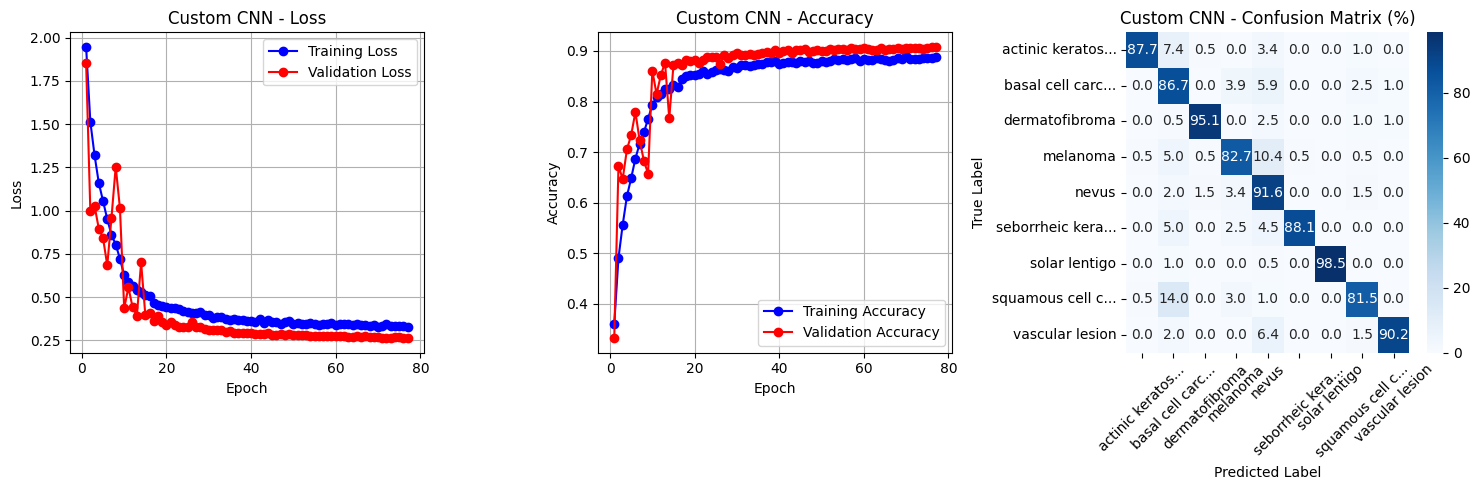


Starting ResNet50

Training ResNet50
Epoch 1/100
459/459 [==============================] - 57s 115ms/step - loss: 0.7464 - accuracy: 0.7621 - val_loss: 3.6892 - val_accuracy: 0.0989 - lr: 1.0000e-04
Epoch 2/100
459/459 [==============================] - 53s 115ms/step - loss: 0.3530 - accuracy: 0.8839 - val_loss: 1.8261 - val_accuracy: 0.3626 - lr: 1.0000e-04
Epoch 3/100
459/459 [==============================] - 53s 115ms/step - loss: 0.2449 - accuracy: 0.9221 - val_loss: 0.3688 - val_accuracy: 0.8839 - lr: 1.0000e-04
Epoch 4/100
459/459 [==============================] - 53s 115ms/step - loss: 0.1978 - accuracy: 0.9375 - val_loss: 0.1029 - val_accuracy: 0.9766 - lr: 1.0000e-04
Epoch 5/100
459/459 [==============================] - 53s 115ms/step - loss: 0.1265 - accuracy: 0.9616 - val_loss: 0.1194 - val_accuracy: 0.9615 - lr: 1.0000e-04
Epoch 6/100
459/459 [==============================] - 53s 116ms/step - loss: 0.0959 - accuracy: 0.9691 - val_loss: 0.0786 - val_accuracy: 0.9766 -

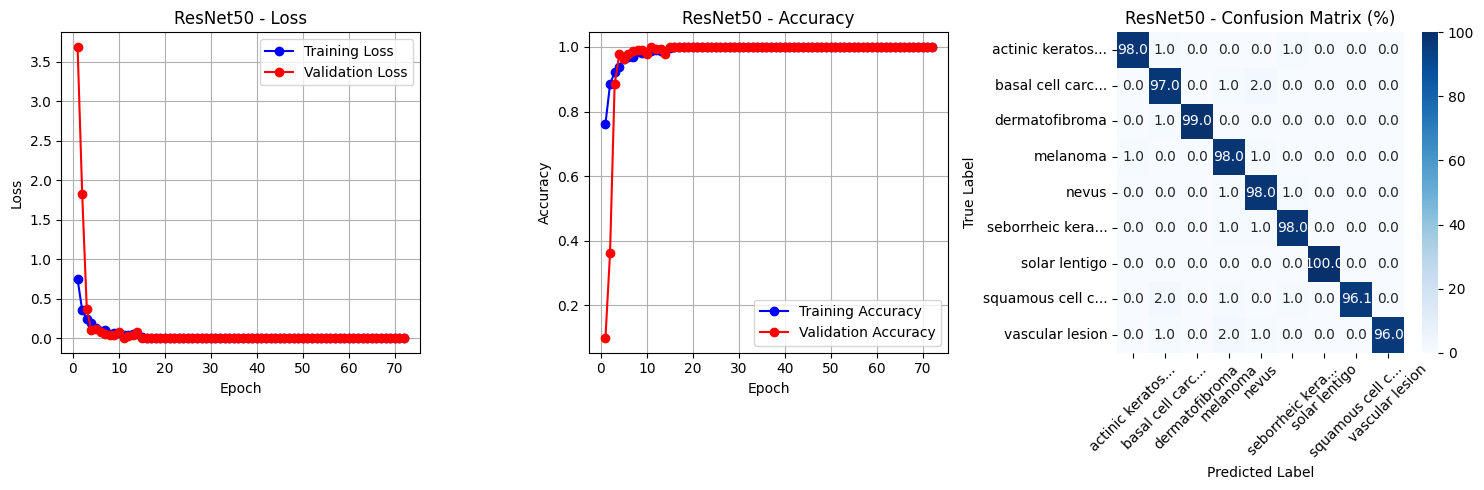


Starting ResNet101

Training ResNet101
Epoch 1/100
459/459 [==============================] - 83s 169ms/step - loss: 0.7444 - accuracy: 0.7627 - val_loss: 2.5392 - val_accuracy: 0.1092 - lr: 1.0000e-04
Epoch 2/100
459/459 [==============================] - 77s 168ms/step - loss: 0.3729 - accuracy: 0.8853 - val_loss: 1.4690 - val_accuracy: 0.5227 - lr: 1.0000e-04
Epoch 3/100
459/459 [==============================] - 78s 169ms/step - loss: 0.2489 - accuracy: 0.9182 - val_loss: 0.1399 - val_accuracy: 0.9615 - lr: 1.0000e-04
Epoch 4/100
459/459 [==============================] - 78s 169ms/step - loss: 0.1750 - accuracy: 0.9451 - val_loss: 0.0740 - val_accuracy: 0.9808 - lr: 1.0000e-04
Epoch 5/100
459/459 [==============================] - 77s 168ms/step - loss: 0.1263 - accuracy: 0.9608 - val_loss: 0.1005 - val_accuracy: 0.9705 - lr: 1.0000e-04
Epoch 6/100
459/459 [==============================] - 77s 168ms/step - loss: 0.1088 - accuracy: 0.9698 - val_loss: 0.1576 - val_accuracy: 0.9519

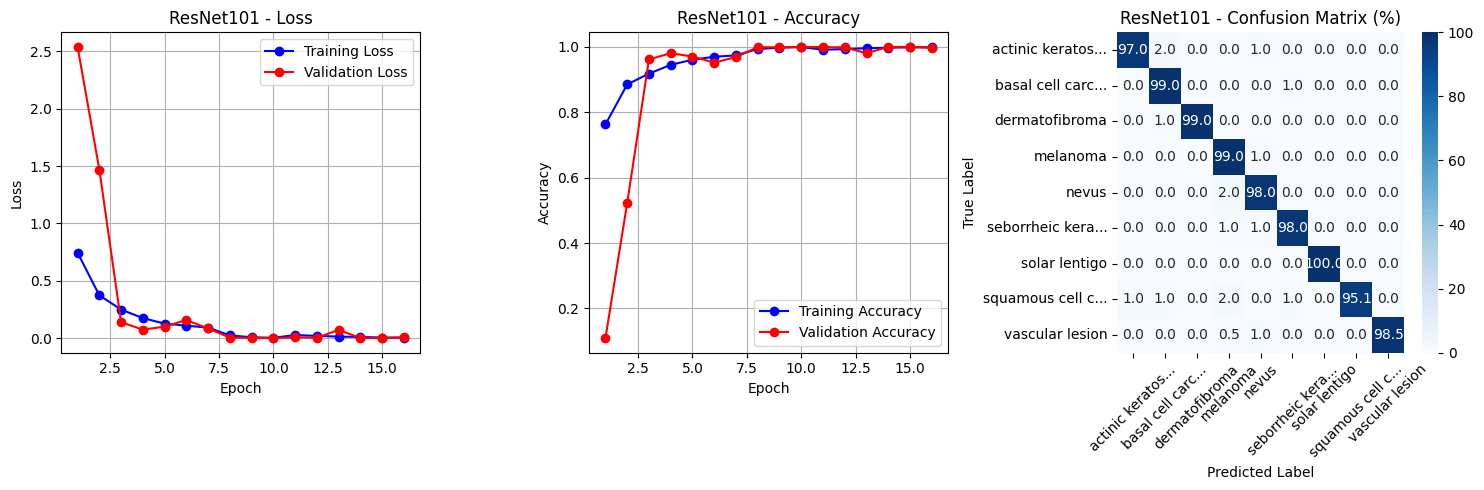


Starting EfficientNet-B0

Training EfficientNet-B0
Epoch 1/100
459/459 [==============================] - 92s 160ms/step - loss: 1.1408 - accuracy: 0.6141 - val_loss: 2.3741 - val_accuracy: 0.1504 - lr: 1.0000e-04
Epoch 2/100
459/459 [==============================] - 74s 161ms/step - loss: 0.4882 - accuracy: 0.8401 - val_loss: 2.3708 - val_accuracy: 0.1504 - lr: 1.0000e-04
Epoch 3/100
459/459 [==============================] - 69s 150ms/step - loss: 0.3785 - accuracy: 0.8738 - val_loss: 2.2067 - val_accuracy: 0.1429 - lr: 1.0000e-04
Epoch 4/100
459/459 [==============================] - 67s 146ms/step - loss: 0.2888 - accuracy: 0.9044 - val_loss: 2.0423 - val_accuracy: 0.2424 - lr: 1.0000e-04
Epoch 5/100
459/459 [==============================] - 69s 151ms/step - loss: 0.2100 - accuracy: 0.9278 - val_loss: 2.3088 - val_accuracy: 0.1023 - lr: 1.0000e-04
Epoch 6/100
459/459 [==============================] - 69s 151ms/step - loss: 0.1518 - accuracy: 0.9498 - val_loss: 2.6278 - val_accu

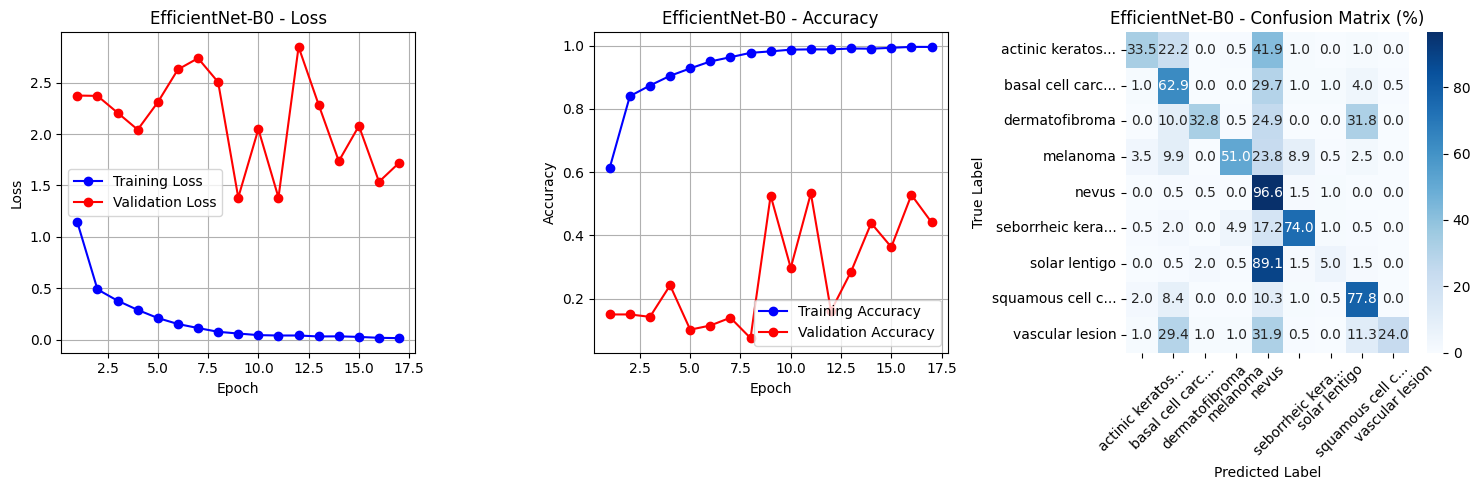


SUMMARY OF ALL MODELS - GAN-AUGMENTED HIBA DATASET
Custom CNN      | Accuracy: 0.892 | Train Time: 1347.99s | Test Time: 7.28s
ResNet50        | Accuracy: 0.978 | Train Time: 3787.57s | Test Time: 12.13s
ResNet101       | Accuracy: 0.982 | Train Time: 1305.01s | Test Time: 38.41s
EfficientNet-B0 | Accuracy: 0.509 | Train Time: 1161.96s | Test Time: 29.63s


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, BatchNormalization, Dropout, Dense, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import gc

EPOCHS = 100

def create_custom_cnn(num_classes):
    """Create custom CNN with dynamic number of classes"""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3)),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(num_classes, activation='softmax')
    ])
    return model

def create_resnet50(num_classes):
    """Create ResNet50 with dynamic number of classes"""
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-10:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(num_classes, activation='softmax')
    ])
    return model

def create_resnet101(num_classes):
    """Create ResNet101 with dynamic number of classes"""
    base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-15:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(num_classes, activation='softmax')
    ])
    return model

def create_efficientnet(num_classes):
    """Create EfficientNet with dynamic number of classes"""
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-20:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(num_classes, activation='softmax')
    ])
    return model

def compile_model(model):
    """Compile model with appropriate optimizer and loss function"""
    model.compile(
        optimizer=Adam(learning_rate=0.0001),  # Using config learning rate
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def prepare_data_for_training_gan(balanced_data):
    """Memory-efficient data preparation for GAN-augmented HIBA dataset"""
    print("\n=== Preparing GAN-Augmented HIBA Data for Training ===")
    
    # Check if we have enough samples for splitting
    if len(balanced_data) < 10:
        print("WARNING: Very few samples. Consider using all data for training.")
        test_size = 0.1
    else:
        test_size = config.TEST_SPLIT
    
    # Split data with stratification (if possible)
    try:
        train_data, test_data = train_test_split(
            balanced_data, test_size=test_size, random_state=42, stratify=balanced_data['label']
        )
    except ValueError:
        # If stratification fails (e.g., too few samples per class)
        print("Warning: Stratification failed, using random split")
        train_data, test_data = train_test_split(
            balanced_data, test_size=test_size, random_state=42
        )
    
    print(f"Training set: {len(train_data)} samples")
    print(f"Test set: {len(test_data)} samples")
    
    # Count synthetic vs original images
    train_synthetic = train_data['synthetic'].sum()
    train_original = len(train_data) - train_synthetic
    test_synthetic = test_data['synthetic'].sum()
    test_original = len(test_data) - test_synthetic
    
    print(f"Training set: {train_original} original + {train_synthetic} synthetic images")
    print(f"Test set: {test_original} original + {test_synthetic} synthetic images")
    
    return train_data, test_data

def create_custom_generator_gan(data, batch_size=16):
    """Custom generator for GAN-augmented HIBA dataset"""
    while True:
        indices = np.random.permutation(len(data))
        for i in range(0, len(data), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_data = data.iloc[batch_indices]
            
            batch_x = []
            batch_y = []
            
            for _, row in batch_data.iterrows():
                # All images should have image_pixel from GAN pipeline
                if 'image_pixel' in row and row['image_pixel'] is not None:
                    img = row['image_pixel']
                    batch_x.append(img)
                    batch_y.append(row['label'])
            
            if len(batch_x) > 0:
                batch_x = np.array(batch_x).astype(np.float32) / 255.0
                batch_y = np.array(batch_y)
                yield batch_x, batch_y

def train_and_evaluate_model_gan(model, model_name, train_data, test_data, label_mapping):
    """Train and evaluate a model for GAN-augmented HIBA dataset"""
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")
    
    # Calculate steps
    train_steps = max(1, len(train_data) // config.BATCH_SIZE)
    val_data_size = max(1, int(len(train_data) * config.VALIDATION_SPLIT))
    val_steps = max(1, val_data_size // config.BATCH_SIZE)
    test_steps = max(1, len(test_data) // config.BATCH_SIZE)
    
    # Create generators
    train_generator = create_custom_generator_gan(train_data, config.BATCH_SIZE)
    val_generator = create_custom_generator_gan(
        train_data.sample(val_data_size, random_state=42), config.BATCH_SIZE
    )
    test_generator = create_custom_generator_gan(test_data, config.BATCH_SIZE)
    
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=6,  # Patience for stability
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
    
    # Training
    start_time = time.time()
    history = model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        epochs=EPOCHS,
        validation_data=val_generator,
        validation_steps=val_steps,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    training_time = time.time() - start_time
    
    # Evaluation
    start_time = time.time()
    test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps, verbose=0)
    
    # Predictions for detailed analysis
    y_pred_list = []
    y_true_list = []
    for i, (batch_x, batch_y) in enumerate(test_generator):
        if i >= test_steps:
            break
        batch_pred = model.predict(batch_x, verbose=0)
        y_pred_list.extend(np.argmax(batch_pred, axis=1))
        y_true_list.extend(batch_y)
    
    y_pred = np.array(y_pred_list)
    y_test = np.array(y_true_list)
    testing_time = time.time() - start_time
    
    # Results analysis
    cm = confusion_matrix(y_test, y_pred)
    cm_percentage = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100
    
    print(f"\nTraining Time: {training_time:.2f} seconds")
    print(f"Testing Time: {testing_time:.2f} seconds")
    print(f"Test Accuracy: {test_accuracy:.3f}")
    
    print(f"\nConfusion Matrix (Percentage) for {model_name}:")
    print(cm_percentage)
    
    # Classification report with proper label names
    # Get unique labels that actually appear in test data
    unique_test_labels = np.unique(np.concatenate([y_test, y_pred]))
    
    # Create labels parameter for classification_report to handle missing classes
    labels = list(range(len(label_mapping)))
    all_class_names = [label_mapping[i] for i in range(len(label_mapping))]
    
    report = classification_report(y_test, y_pred, labels=labels, target_names=all_class_names, digits=3, zero_division=0)
    print(f"\nClassification Report for {model_name}:")
    print(report)
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    epochs_range = range(1, len(history.history['loss']) + 1)
    plt.plot(epochs_range, history.history['loss'], 'bo-', label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], 'ro-', label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history.history['accuracy'], 'bo-', label='Training Accuracy')
    plt.plot(epochs_range, history.history['val_accuracy'], 'ro-', label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Confusion matrix heatmap
    plt.subplot(1, 3, 3)
    
    # Handle case where confusion matrix might be smaller than expected number of classes
    expected_size = len(label_mapping)
    actual_size = cm_percentage.shape[0]
    
    if actual_size < expected_size:
        # Pad the confusion matrix with zeros for missing classes
        padded_cm = np.zeros((expected_size, expected_size))
        unique_labels = np.unique(np.concatenate([y_test, y_pred]))
        for i, label in enumerate(unique_labels):
            for j, pred_label in enumerate(unique_labels):
                padded_cm[label, pred_label] = cm_percentage[i, j]
        cm_to_plot = padded_cm
        plot_class_names = [label_mapping[i] for i in range(len(label_mapping))]
    else:
        cm_to_plot = cm_percentage
        plot_class_names = [label_mapping[i] for i in range(actual_size)]
    
    # Shorten class names for better display
    short_names = [name[:15] + '...' if len(name) > 15 else name for name in plot_class_names]
    
    sns.heatmap(cm_to_plot, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=short_names, yticklabels=short_names)
    plt.title(f'{model_name} - Confusion Matrix (%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Clean up memory
    del model
    tf.keras.backend.clear_session()
    gc.collect()
    
    return history, training_time, testing_time, test_accuracy

def run_gan_model_comparison(balanced_data, label_mapping):
    """Run comparison of different models on GAN-augmented HIBA dataset"""
    print("\n=== GAN-Augmented HIBA Model Comparison Pipeline ===")
    
    # Get number of classes
    num_classes = len(label_mapping)
    print(f"Number of classes: {num_classes}")
    print(f"Classes: {list(label_mapping.values())}")
    
    # Show dataset composition
    print(f"\nDataset composition:")
    print(f"Total samples: {len(balanced_data)}")
    synthetic_count = balanced_data['synthetic'].sum()
    original_count = len(balanced_data) - synthetic_count
    print(f"Original images: {original_count}")
    print(f"GAN-generated images: {synthetic_count}")
    print(f"Synthetic ratio: {synthetic_count/len(balanced_data)*100:.1f}%")
    
    # Show class distribution
    print(f"\nClass distribution:")
    class_counts = balanced_data['dx'].value_counts()
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} images")
    
    # Prepare data
    train_data, test_data = prepare_data_for_training_gan(balanced_data)
    
    # Model configurations
    models_config = [
        (create_custom_cnn, "Custom CNN"),
        (create_resnet50, "ResNet50"),
        (create_resnet101, "ResNet101"),
        (create_efficientnet, "EfficientNet-B0")
    ]
    
    results = {}
    
    for model_func, model_name in models_config:
        print(f"\n{'='*60}")
        print(f"Starting {model_name}")
        print(f"{'='*60}")
        
        try:
            model = compile_model(model_func(num_classes))
            history, train_time, test_time, test_acc = train_and_evaluate_model_gan(
                model, model_name, train_data, test_data, label_mapping
            )
            results[model_name] = {
                'history': history,
                'train_time': train_time,
                'test_time': test_time,
                'test_accuracy': test_acc
            }
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            results[model_name] = {
                'error': str(e),
                'test_accuracy': 0.0,
                'train_time': 0.0,
                'test_time': 0.0
            }
    
    # Summary
    print(f"\n{'='*60}")
    print("SUMMARY OF ALL MODELS - GAN-AUGMENTED HIBA DATASET")
    print(f"{'='*60}")
    for name, result in results.items():
        if 'error' in result:
            print(f"{name:15} | ERROR: {result['error']}")
        else:
            print(f"{name:15} | Accuracy: {result['test_accuracy']:.3f} | Train Time: {result['train_time']:.2f}s | Test Time: {result['test_time']:.2f}s")
    
    return results

# Configuration for dropout rate (add this if not already defined)
class ConfigExtension:
    DROPOUT_RATE = 0.5
    BATCH_SIZE = 16
    IMAGE_SIZE = 224
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.2

# Merge with existing config if available, otherwise create new
try:
    config.DROPOUT_RATE = 0.5
except NameError:
    config = ConfigExtension()

# Run the model comparison using the loaded balanced dataset
print("Running GAN-augmented model training...")
model_results = run_gan_model_comparison(balanced_data, label_mapping)